In [1]:
#import statements
import pandas as pd #used for dataframe functions and attributes
import matplotlib.pyplot as plt #used for graphing
import seaborn as sns #used for graphing
import scipy.stats as stats #used for statistical attributes
from statsmodels.stats.multicomp import pairwise_tukeyhsd #used for hypothesis testing (ANOVA)


In [2]:
#importing the dataset file
survey_df = pd.read_csv(r"C:\Users\Andrew\Desktop\The Frontier Institute - Programs\Data Science Program Stuff\survey_results_public.csv")

In [3]:
#viewing the data, and unique values for the Age column
survey_df["Age"].unique()

<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

In [4]:
#dropping unnecessary columns
survey_df = survey_df.drop(columns = ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 
                                      'JobSatPoints_10', 'JobSatPoints_11', 'TimeSearching', 'TimeAnswering', 'SurveyLength', 'SurveyEase', 'Check', 'SOVisitFreq', 'SOAccount',
                                      'SOPartFreq', 'SOHow', 'SOComm', 'NEWSOSites', 'Frequency_1', 'Frequency_2', 'Frequency_3', 'Knowledge_1' , 'Knowledge_2', 'Knowledge_3', 
                                      'Knowledge_4', 'Knowledge_5', 'Knowledge_6', 'Knowledge_7', 'Knowledge_8', 'Knowledge_9'])
survey_df.head(1)

,ResponseId,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
survey_df.head(15)

,ResponseId,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,Yes,Individual contributor,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,NaN,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,First-party knowledge base,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,NaN,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,Traditional public search engine;AI-powered se...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#Checking for null values in YearsCodePro column
print(survey_df.loc[survey_df["YearsCodePro"].isnull(), "YearsCodePro"])


0        NaN
3        NaN
4        NaN
5        NaN
7        NaN
        ... 
65427    NaN
65429    NaN
65430    NaN
65433    NaN
65436    NaN
Name: YearsCodePro, Length: 13827, dtype: str


In [7]:
# #DON'T RUN, not needed, as will use just the regular strings

# age_numbers = []

# #for loop: cycles through the dataset, and uses conditional to assign a numerical value to age ranges
# #Adds the numbers in a list, into a new column, corresponding to each row
# for age in survey_df['Age']:
#     if age == 'Under 18 years old':
#         age_numbers.append(1)      # 1 --> <18
#     elif age == '18-24 years old':
#         age_numbers.append(2)      # 2 --> 18-24
#     elif age == '25-34 years old':
#         age_numbers.append(3)      # 3 --> 25-34
#     elif age == '35-44 years old':
#         age_numbers.append(4)      # 4 --> 35-44
#     elif age == '45-54 years old':
#         age_numbers.append(5) # 5 --> 45-54
#     elif age == '55-64 years old':
#         age_numbers.append(6) # 6 --> 55-64
#     elif age == '65 years or older':
#         age_numbers.append(7) # 7 --> 65+
#     else:
#         age_numbers.append(-0)    # For 'prefer not to say'

# # Put the list back into the dataset
# survey_df['AgeCategory'] = age_numbers
# survey_df.insert(3, 'AgeCategory', survey_df.pop('AgeCategory')) #Moves the column right beside 'Age', the 3rd index
# survey_df.head(3)

In [8]:
# #DON'T RUN, not needed, as will use just the regular strings

# #Gets counts of the age category, sorted from 0-7
# age_counts = survey_df['AgeCategory'].value_counts().sort_index()

# #plotting bar ,graph, with some color
# plt.bar(age_counts.index, age_counts.values, color='skyblue', edgecolor='black')

# #using labels to force x axis to read the age ranges, instead of 0-7
# labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'No say']
# plt.xticks(ticks=age_counts.index[:8], labels=labels)

# plt.title("Number of Developers in Each Age Category")
# plt.xlabel("Age Range")
# plt.ylabel("Count")
# plt.show()

In [9]:
#drops all rows with null values in the "YearsCodePro" column
survey_df = survey_df.dropna(subset=['YearsCodePro'])

corrected_years = [] #empty list to store corrected years

#for loop, cycles through "YearsCodePro" column, and replaces string values with rounded integers
for year in survey_df['YearsCodePro']:
   if year == "Less than 1 year":  #rounds "Less than 1 year" to 0 years
        corrected_years.append(0)
   elif year == "More than 50 years":
      corrected_years.append(51)  #rounds "More than 50 years" to 51 years
   else:
       corrected_years.append(int(year))       
       
survey_df['YearsCodePro'] = corrected_years


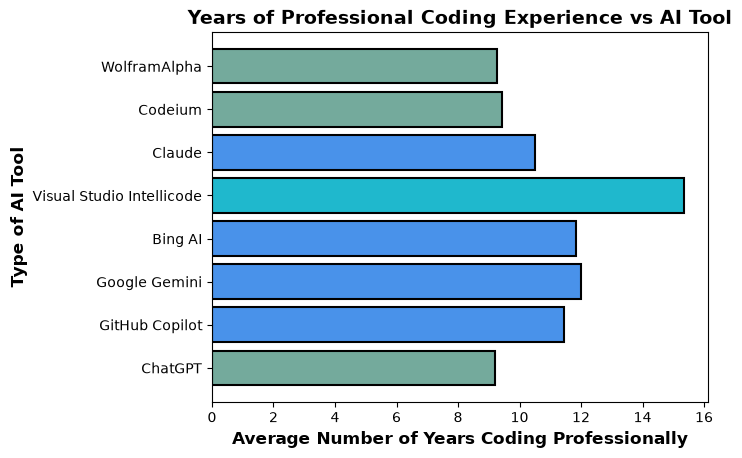

In [10]:
#Purpose of graph: shows that those who use AI tools in general have lengthy amounts of coding experience

#groups survey_df by the type of AI tool used, then gets the 'YearsCodePro" column --> gets the average per group
survey_filtered = survey_df.groupby('AISearchDevHaveWorkedWith')['YearsCodePro'].mean()

#filters to only look for a few types of AI tools in a list
averages = survey_filtered.loc[['ChatGPT', 'GitHub Copilot', 'Google Gemini', 'Bing AI',
       'Visual Studio Intellicode', 'Claude', 'Codeium', 'WolframAlpha']]

x = averages.index #names of the AI tools
y = averages.values #averages of their years coding professionally

plt.barh(x, y, color=['#74AA9C', '#4992ea', '#4992ea', '#4992ea', '#1FB8CD', '#4992ea', '#74AA9C', '#74AA9C'], edgecolor='black', linewidth=1.5)

plt.title("Years of Professional Coding Experience vs AI Tool", fontsize=14, fontweight='bold')
plt.xlabel("Average Number of Years Coding Professionally", fontsize=12, fontweight='bold')
plt.ylabel("Type of AI Tool", fontsize=12, fontweight='bold',)
plt.show()

In [11]:
unique_values = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', 
                 '55-64 years old', '65 years or older', 'Prefer not to say']


ai_age = survey_df[["AISearchDevHaveWorkedWith", "Age"]].copy()
ai_age = ai_age.dropna() #drops null values

#Remove 'Prefer not to say', we don't need this input
ai_age = ai_age[ai_age["Age"] != "Prefer not to say"]


In [12]:
ai_age["AISearchDevHaveWorkedWith"].head(2)

9                               ChatGPT;Google Gemini
15    ChatGPT;Google Gemini;Visual Studio Intellicode
Name: AISearchDevHaveWorkedWith, dtype: str

In [13]:
#Splits the tools in each row, in a new row called 'AI Tool'
ai_age["AITool"] = (ai_age["AISearchDevHaveWorkedWith"].str.split(";"))
ai_age

,AISearchDevHaveWorkedWith,Age,AITool
9,ChatGPT;Google Gemini,35-44 years old,"[ChatGPT, Google Gemini]"
15,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,"[ChatGPT, Google Gemini, Visual Studio Intelli..."
17,ChatGPT,18-24 years old,[ChatGPT]
18,ChatGPT;GitHub Copilot,25-34 years old,"[ChatGPT, GitHub Copilot]"
20,ChatGPT,25-34 years old,[ChatGPT]
...,...,...,...
65367,ChatGPT;GitHub Copilot,25-34 years old,"[ChatGPT, GitHub Copilot]"
65388,ChatGPT;Codeium;Google Gemini,25-34 years old,"[ChatGPT, Codeium, Google Gemini]"
65399,ChatGPT,35-44 years old,[ChatGPT]
65404,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,"[ChatGPT, Claude, GitHub Copilot, WolframAlpha]"


In [14]:
#Puts each AI tool in a separate row, but they still correspond to the same people
ai_age = ai_age.explode("AITool").reset_index(drop=True) #.reset_index() so that rows from the same people's index won't repeat
ai_age

,AISearchDevHaveWorkedWith,Age,AITool
0,ChatGPT;Google Gemini,35-44 years old,ChatGPT
1,ChatGPT;Google Gemini,35-44 years old,Google Gemini
2,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,ChatGPT
3,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Google Gemini
4,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Visual Studio Intellicode
...,...,...,...
87092,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,Claude
87093,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,GitHub Copilot
87094,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,WolframAlpha
87095,ChatGPT;Google Gemini,35-44 years old,ChatGPT


In [15]:
#Remove extra spaces from tool names
ai_age["AITool"] = ai_age['AITool'].str.strip()

#Find the eight most commonly reported AI tools
top_tools = (ai_age["AITool"].value_counts().head(8).index)
top_tools

Index(['ChatGPT', 'GitHub Copilot', 'Google Gemini', 'Bing AI',
       'Visual Studio Intellicode', 'Claude', 'Codeium', 'Perplexity AI'],
      dtype='str', name='AITool')

In [16]:
#A new df with the only the top 8 AI tools 
ai_age_top = ai_age[ai_age["AITool"].isin(top_tools)]
ai_age_top

,AISearchDevHaveWorkedWith,Age,AITool
0,ChatGPT;Google Gemini,35-44 years old,ChatGPT
1,ChatGPT;Google Gemini,35-44 years old,Google Gemini
2,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,ChatGPT
3,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Google Gemini
4,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Visual Studio Intellicode
...,...,...,...
87091,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,ChatGPT
87092,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,Claude
87093,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,GitHub Copilot
87095,ChatGPT;Google Gemini,35-44 years old,ChatGPT


In [17]:
#creating a percentage table
age_percent = pd.crosstab(ai_age_top["AITool"], ai_age_top["Age"], normalize = "index") * 100
age_percent

#pd.crosstab() ---> makes a table that compared AI tool and age group
#normalize ---> caluclates percentrages within each AI tool

Age,18-24 years old,25-34 years old,35-44 years old,45-54 years old,55-64 years old,65 years or older,Under 18 years old
AITool,,,,,,,
Bing AI,24.780135,37.092602,21.900328,10.484566,3.448870,0.724263,1.569236
ChatGPT,20.701526,42.352066,23.635405,9.108671,2.822230,0.521027,0.859075
Claude,26.170010,38.490926,21.235275,9.391913,3.056351,0.318370,1.337154
Codeium,21.976074,40.053168,22.862206,10.722198,2.614089,0.310146,1.462118
GitHub Copilot,19.912808,41.180629,25.515494,9.573465,2.739484,0.306351,0.771769
Google Gemini,25.611927,40.264798,21.562083,8.277704,2.603471,0.411660,1.268358
Perplexity AI,24.331021,39.940535,21.605550,8.671952,2.923687,0.842418,1.684836
Visual Studio Intellicode,19.947309,34.474972,24.670681,13.643207,5.043282,0.978547,1.242002


In [18]:
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', 
                 '55-64 years old', '65 years or older']

age_percent = age_percent.reindex(index = top_tools, columns = age_order, fill_value = 0)
#index ---> top_tools orders tools from most commmon to least common
#columns ---> age order orders ages from youngest to olders
#fill values ---> 0  fills any missing info with 0, unnecesarry, but just leaving it there

age_percent = age_percent.round(2) #rounds to 2 decimals


In [19]:
age_percent #checking the AI tool table

Age,Under 18 years old,18-24 years old,25-34 years old,35-44 years old,45-54 years old,55-64 years old,65 years or older
AITool,,,,,,,
ChatGPT,0.86,20.70,42.35,23.64,9.11,2.82,0.52
GitHub Copilot,0.77,19.91,41.18,25.52,9.57,2.74,0.31
Google Gemini,1.27,25.61,40.26,21.56,8.28,2.60,0.41
Bing AI,1.57,24.78,37.09,21.90,10.48,3.45,0.72
Visual Studio Intellicode,1.24,19.95,34.47,24.67,13.64,5.04,0.98
Claude,1.34,26.17,38.49,21.24,9.39,3.06,0.32
Codeium,1.46,21.98,40.05,22.86,10.72,2.61,0.31
Perplexity AI,1.68,24.33,39.94,21.61,8.67,2.92,0.84


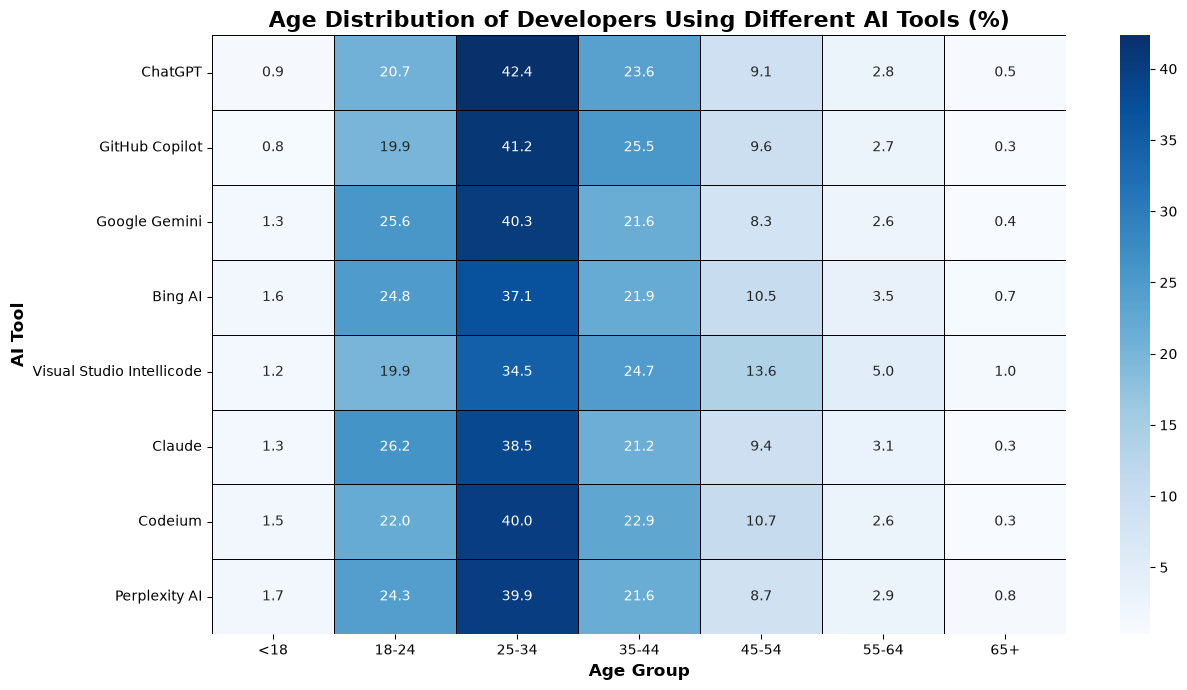

In [20]:
#making the heatmap

label = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
plt.figure(figsize = (13, 7)) #defining a figure size

sns.heatmap(age_percent, annot = True, fmt = ".1f", cmap = "Blues", xticklabels=label, 
            linewidths=0.5,       # <--- Thickness of the grid lines
            linecolor='black'    # <--- Color of the grid lines)
            )

plt.title("Age Distribution of Developers Using Different AI Tools (%)", fontweight = 'bold', fontsize=16)
plt.xlabel("Age Group", fontweight = 'bold', fontsize=12)
plt.ylabel("AI Tool", fontweight = 'bold', fontsize=12)

plt.tight_layout()
plt.savefig("Age Range-AI Tool - Heat Map", dpi = 300, bbox_inches = "tight")
plt.show()

#annot = True --> displayed the percentange inside eacch cell
#fmt = ".2f" ---> displays two decimal places
#cmap = "Blues" ---> theme
#darker cells, larger percentages

In [21]:
#Chi-Squared Test: Age Range to AI Tool

#Create the crosstable with raw counts (no normalize='index', no percentage)
new_crosstab = pd.crosstab(ai_age_top["AITool"], ai_age_top["Age"])

result = stats.chi2_contingency(new_crosstab)

chi2_stat = result.statistic
p_val = result.pvalue

print("Chi-Squared:", chi2_stat)
print("P-value", p_val)

#Result: < than 0.05
#Data is significant, it's very unlikely we got this just by chance
#It's likely that age influences AI choice, strong

Chi-Squared: 659.5609263484585
P-value 6.076023870739281e-112


In [22]:
#Chi-Squared Test: Education Level to AI Tool
ed_tool = survey_df.copy() #copy of the main dataframe

ed_tool["AITool"] = (ed_tool["AISearchDevHaveWorkedWith"].str.split(";")) #removes ";"
ed_tool = ed_tool.explode("AITool").reset_index(drop=True) #sets the Ai Tools to be individual again, new rows

ed_tool["AITool"] = ed_tool['AITool'].str.strip() #clears any unnecessary stuff
top_tools2 = (ed_tool["AITool"].value_counts().head(8).index) #only includes the top 8 AI tools

ed_tool_top_tools = ed_tool[ed_tool["AITool"].isin(top_tools2)] 

age_percent = age_percent.reindex(index = top_tools, columns = age_order, fill_value = 0)
#index ---> top_tools orders tools from most commmon to least common
#columns ---> age order orders ages from youngest to olders
#fill values ---> 0  fills any missing info with 0, unnecesarry, but just leaving it there

#Makes the crosstable
ed_tool_table = pd.crosstab(ed_tool_top_tools["AITool"], ed_tool_top_tools["EdLevel"])

result2 = stats.chi2_contingency(ed_tool_table)

chi2_stat2 = result2.statistic
p_val2 = result2.pvalue

print("Chi-Squared:", chi2_stat2)
print("P-value", p_val2)

#Result: < than 0.05
#Data is significant, it's very unlikely we got this just by chance
#It's likely that education level influences AI tool use, strongest data so far, strin

Chi-Squared: 248.44039731849975
P-value 1.7993947826615652e-28


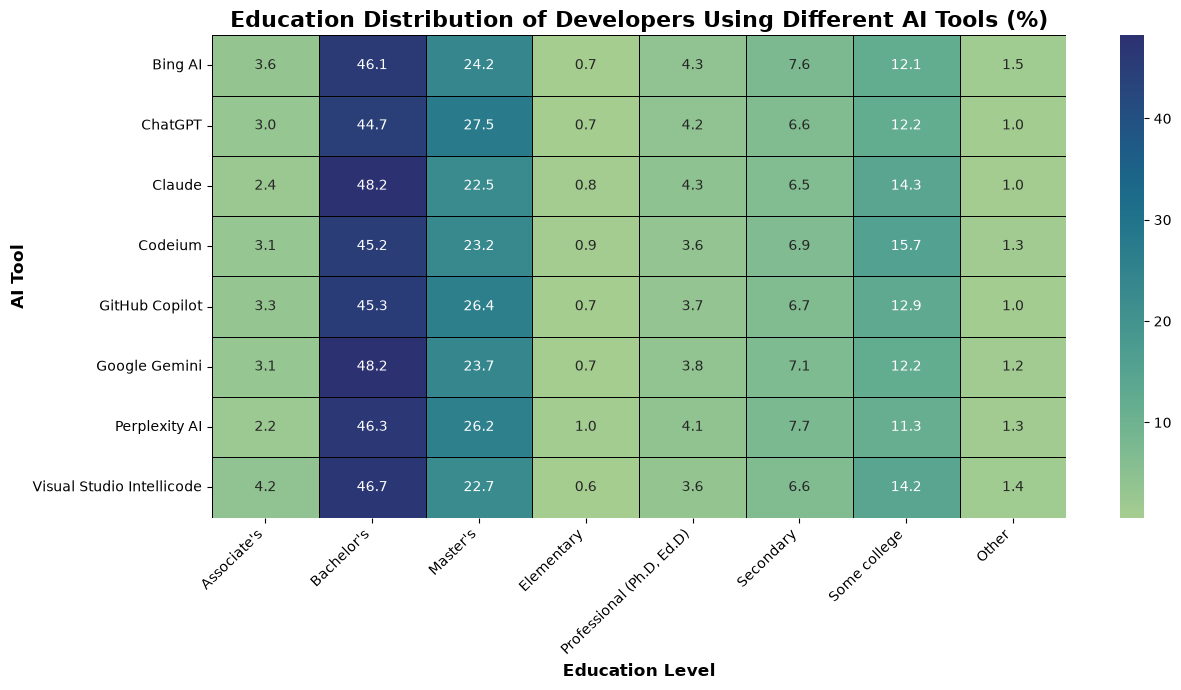

In [23]:
#making the heatmap

label = ["Associate's", "Bachelor's", "Master's", "Elementary", "Professional (Ph.D, Ed.D)", "Secondary", "Some college", "Other"]
edu_percent = pd.crosstab(ed_tool_top_tools["AITool"], ed_tool_top_tools["EdLevel"], normalize = "index") * 100

plt.figure(figsize = (13, 7)) #defining a figure size

sns.heatmap(edu_percent, annot = True, fmt = ".1f", cmap = "crest", xticklabels = label,
            linewidths=0.5,       # <--- Thickness of the grid lines
            linecolor='black'    # <--- Color of the grid lines)
            )

plt.title("Education Distribution of Developers Using Different AI Tools (%)", fontweight = 'bold', fontsize=16)
plt.xlabel("Education Level", fontweight = 'bold', fontsize=12)
plt.ylabel("AI Tool", fontweight = 'bold', fontsize=12)
plt.xticks(rotation = 44, ha="right")

plt.tight_layout()
plt.savefig("Education-AI Tool - Heat Map", dpi = 300, bbox_inches = "tight")
plt.show()

#annot = True --> displayed the percentange inside eacch cell
#fmt = ".2f" ---> displays two decimal places
#cmap = "Blues" ---> theme
#darker cells, larger percentages

In [24]:
survey_df["DevType"].value_counts()

DevType
Developer, full-stack                            17431
Developer, back-end                               9586
Developer, front-end                              3100
Developer, desktop or enterprise applications     2348
Developer, mobile                                 1887
Developer, embedded applications or devices       1560
Other (please specify):                           1553
Student                                           1539
Engineering manager                               1096
Academic researcher                               1095
Data engineer                                     1074
DevOps specialist                                  974
Data scientist or machine learning specialist      953
Research & Development role                        883
Senior Executive (C-Suite, VP, etc.)               702
Cloud infrastructure engineer                      590
Developer, game or graphics                        537
Developer, AI                                      492
De

In [25]:
  #Makes a dictioanry to sort the developer roles in multiple, simpler categories              
                #developers
changed_names = {"Developer, full-stack": "Developer",
                 "Developer, back-end": "Developer",
                 "Developer, front-end": "Developer",
                 "Developer, desktop or enterprise applications": "Developer",
                 "Developer, mobile": "Developer",
                 "Developer, embedded applications or devices": "Developer",
                 "Developer, game or graphics": "Developer",
                 "Developer, AI": "Developer",
                 "Developer, QA or test": "Developer",
                 "Developer Experience": "Developer",
                 "Developer Advocate": "Developer",

                 # 2. Data & AI
                'Data engineer': 'Data & AI',
                'Data scientist or machine learning specialist': 'Data & AI',
                'Developer, AI': 'Data & AI',
                'Data or business analyst': 'Data & AI',

                # 3. Education & Research
                'Student': 'Education & Research',
                'Academic researcher': 'Education & Research',
                'Educator': 'Education & Research',
                'Scientist': 'Education & Research',
                'Research & Development role': 'Education & Research',

                # 4. Management & Business
                'Other (please specify):': 'Management & Business',
                'Engineering manager': 'Management & Business',
                'Senior Executive (C-Suite, VP, etc.)': 'Management & Business',
                'Project manager': 'Management & Business',
                'Product manager': 'Management & Business',
                'Marketing or sales professional': 'Management & Business',
                'Designer': 'Management & Business',
                'Developer Advocate': 'Management & Business',
                'Security professional': 'Management & Business',
                'Blockchain': 'Management & Business'
    
}

In [26]:
#Chi-Squared Test: Dev Job Role to AI Tool
role_tool = survey_df.copy() #copy of the main dataframe
role_tool = role_tool.dropna(subset=['DevType']) #drops all null values
role_tool['DevType'] = role_tool['DevType'].map(changed_names)

role_tool["AITool"] = (role_tool["AISearchDevHaveWorkedWith"].str.split(";")) #removes ";"
role_tool = role_tool.explode("AITool").reset_index(drop=True) #sets the Ai Tools to be individual again, new rows

role_tool["AITool"] = role_tool['AITool'].str.strip() #clears any unnecessary stuff
top_tools2 = (role_tool["AITool"].value_counts().head(8).index) #only includes the top 8 AI tools
role_tool_top_tools = role_tool[role_tool["AITool"].isin(top_tools2)] 

#Makes the crosstable
role_tool_table = pd.crosstab(role_tool_top_tools["AITool"], role_tool_top_tools["DevType"])

result3 = stats.chi2_contingency(role_tool_table)

chi2_stat3 = result3.statistic
p_val3 = result3.pvalue

print("Chi-Squared:", chi2_stat3)
print("P-value", p_val3)

#Result: < than 0.05
#Data is significant, it's very unlikely we got this just by chance
#It's likely that job role influences AI tool use

Chi-Squared: 511.94742842759854
P-value 4.697915810959698e-95


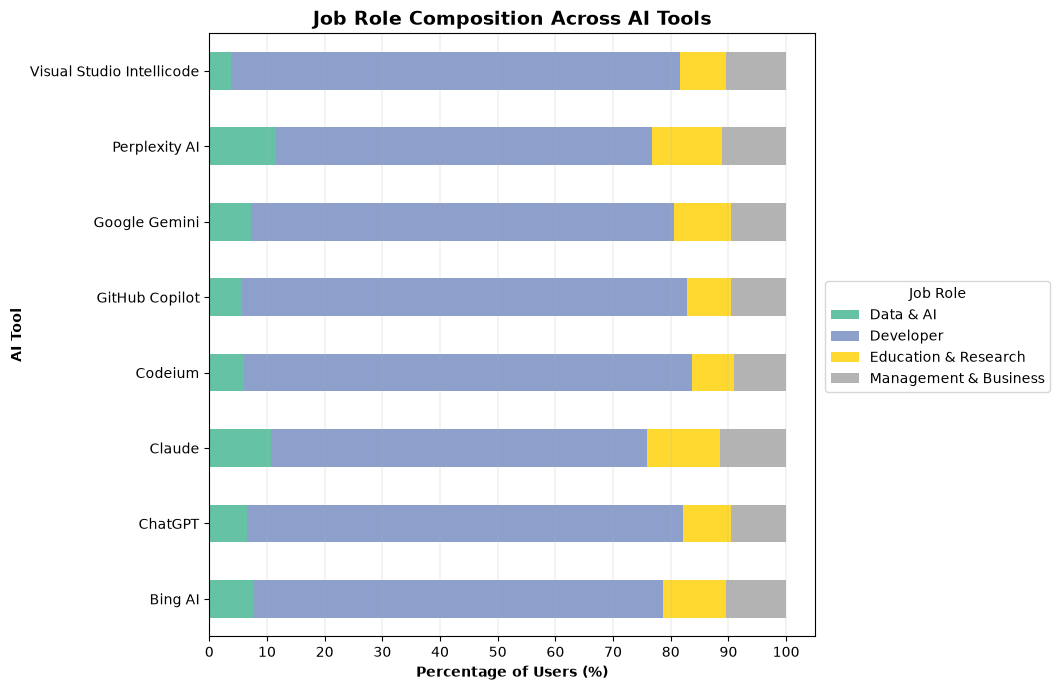

In [27]:
#plot for DEvType to AITool

role_tool_percentage = pd.crosstab(
    role_tool_top_tools["AITool"],
    role_tool["DevType"],
    normalize = 'index' #nomalizes each row (makes percentages)
    ) * 100 #multiply by 100 to get clean %s


role_tool_percentage.plot(
    kind = 'barh', #makes it horizontal, cuz AI tool names are big
    stacked = True, #stacks job roles on top of each other
    figsize = (12,7), #width and height
    colormap= 'Set2'
)

plt.title("Job Role Composition Across AI Tools", fontweight='bold', fontsize=14)
plt.xlabel("Percentage of Users (%)", fontweight='bold')
plt.ylabel("AI Tool", fontweight='bold')

# 4. Move the legend outside the chart box so it doesn't overlap your bars
plt.legend(title="Job Role", bbox_to_anchor=(1.4, 0.6))

# 5. Prevent labels from getting cut off at the edges
plt.tight_layout()
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.grid(axis ='x', linewidth=0.2,)
plt.savefig("DevType-AI Tool -Stacked Bar Plot", dpi = 300, bbox_inches = "tight")
plt.show()

In [28]:
#ANOVA Test: Years Coding Professionally to AI Tool
anova_df = survey_df.dropna(subset=['YearsCodePro', 'AISearchDevHaveWorkedWith']).copy() #copy of df, drops nulls

#splits AI Tool names into separate rows
anova_df['AITool'] = anova_df['AISearchDevHaveWorkedWith'].str.split(';')
anova_df = anova_df.explode('AITool')
anova_df['AITool'] = anova_df['AITool'].str.strip()

#filters for top 8 AI tools, and makes the df only use those top 8
top_tools = anova_df['AITool'].value_counts().head(8).index
anova_df = anova_df[anova_df['AITool'].isin(top_tools)]

#drops any nans (double checking), and makes sure column is numeric
anova_df['YearsCodePro'] = pd.to_numeric(anova_df['YearsCodePro'])
anova_df = anova_df.dropna(subset=['YearsCodePro'])

#groups the AI Tools by name
grouped_data = [group['YearsCodePro'].values for name, group in anova_df.groupby('AITool')]

f_stat, p_val = stats.f_oneway(*grouped_data) #gives stats on each AI Tool

print("F-statistic:", f_stat)
print("P-value:", p_val)
print()

#Tukey table with comparison info
tukey = pairwise_tukeyhsd(endog = anova_df['YearsCodePro'], groups = anova_df['AITool'], alpha = 0.05)

print(tukey)


F-statistic: 63.66271694991867
P-value: 7.19813339761807e-92

              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
    group1               group2          meandiff p-adj   lower   upper  reject
-------------------------------------------------------------------------------
       Bing AI                   ChatGPT  -0.0897 0.9959 -0.4587  0.2793  False
       Bing AI                    Claude   -0.497 0.1461 -1.0704  0.0764  False
       Bing AI                   Codeium  -0.4905 0.2849 -1.1325  0.1516  False
       Bing AI            GitHub Copilot   0.4766 0.0059  0.0831  0.8701   True
       Bing AI             Google Gemini  -0.8004    0.0 -1.2361 -0.3646   True
       Bing AI             Perplexity AI  -0.5283 0.2443 -1.1972  0.1406  False
       Bing AI Visual Studio Intellicode   1.9898    0.0  1.4985  2.4811   True
       ChatGPT                    Claude  -0.4073 0.1744 -0.8912  0.0767  False
       ChatGPT                   Codeium  -0.4007 0.3793 -

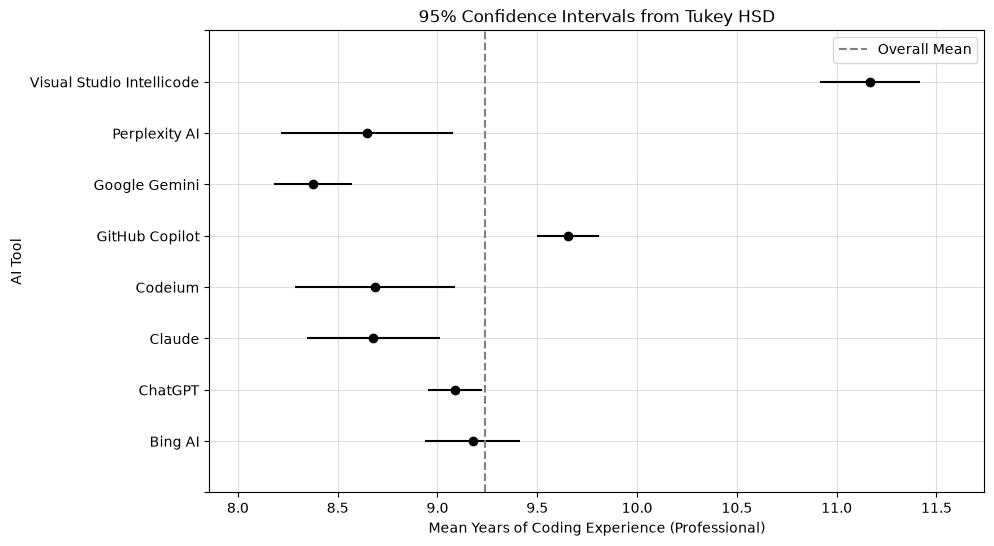

In [29]:
overall_mean = anova_df['YearsCodePro'].mean() #creating a line that is the mean years of coding experience for all respondents

tukey.plot_simultaneous(figsize = (10,6))

#plotting mean line for reference
plt.axvline(overall_mean, color = 'gray', linestyle = '--', linewidth = 1.5, label = 'Overall Mean')

plt.title('95% Confidence Intervals from Tukey HSD')
plt.ylabel('AI Tool')
plt.xlabel("Mean Years of Coding Experience (Professional)")
plt.grid(axis = 'both', alpha = 0.4) #creating a grid, looks nice
plt.legend()
plt.savefig("YearsCodePro-AI Tool -Tukey Confidence Plot", dpi = 300, bbox_inches = "tight")
plt.show()